In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression

In [ ]:
df = np.round(pd.read_csv('../../../DataBox/startups.csv')[['R&D Spend','Administration','Marketing Spend','Profit']])

# Ground Truth for verification later
df_orig = df.copy()

# Randomly remove 20% of values (set to NaN)
# We flatten the dataframe to sample individual cells, not just rows

np.random.seed(90)
mask = np.random.choice([True, False], size=df.shape, p=[0.2, 0.8]) # 10% True (missing)
df_missing = df.mask(mask)

df_missing.isnull().mean() * 100

R&D Spend          32.0
Administration     14.0
Marketing Spend    18.0
Profit             14.0
dtype: float64

In [3]:
def manual_mice(df_orig, iterations=500000):
    # Step 1: Initial Imputation (Mean)
    df_current = df_orig.copy()
    for col in df_current.columns:
        df_current[col] = df_current[col].fillna(df_current[col].mean())
    
    print("Initial (Iteration 0) State:")
    print(df_current, "\n")

    # Step 2: Iterative process
    for i in range(1, iterations + 1):
        df_old = df_current.copy()
        
        # Loop through each column that had missing values
        for target_col in df_orig.columns:
            # Only update if the original column had NaNs
            if df_orig[target_col].isnull().any():
                
                # Identify missing indices for the current target column
                missing_idx = df_orig[df_orig[target_col].isnull()].index
                train_idx = df_orig[df_orig[target_col].notnull()].index
                
                # Temporarily set the imputed values back to NaN to build the model
                df_current.loc[missing_idx, target_col] = np.nan
                
                # Define X and y (using df_current to get the most updated values of other columns)
                X = df_current.drop(columns=[target_col])
                y = df_current[target_col]
                
                # Fit model on rows where target was NOT missing
                lr = LinearRegression()
                lr.fit(X.loc[train_idx], y.loc[train_idx])
                
                # Predict for missing values
                predictions = lr.predict(X.loc[missing_idx])
                
                # Update the missing values in df_current
                df_current.loc[missing_idx, target_col] = predictions
        
        # Calculate convergence (Difference between this iteration and the last)
        diff = (df_current - df_old).abs().sum().sum()
        print(f"Iteration {i} - Total Change: {diff:.4f}")
        print(df_current, "\n")
        
        if diff < 0.0001:  # Break if values stop changing
            print("Converged!")
            print(i)
            break
            
    return df_current

In [4]:
df_imputed = manual_mice(df_missing)

Initial (Iteration 0) State:
        R&D Spend  Administration  Marketing Spend         Profit
0    75641.852941   119206.837209    471784.000000  192262.000000
1    75641.852941   151378.000000    443899.000000  191792.000000
2   153442.000000   101146.000000    407935.000000  191050.000000
3   144372.000000   118672.000000    211577.463415  182902.000000
4   142107.000000    91392.000000    366168.000000  166188.000000
5   131877.000000    99815.000000    211577.463415  156991.000000
6   134615.000000   119206.837209    127717.000000  156123.000000
7   130298.000000   145530.000000    323877.000000  155753.000000
8   120543.000000   148719.000000    311613.000000  152212.000000
9   123335.000000   108679.000000    304982.000000  149760.000000
10  101913.000000   110594.000000    229161.000000  146122.000000
11  100672.000000    91791.000000    249745.000000  144259.000000
12   93864.000000   127320.000000    249839.000000  141586.000000
13   91992.000000   135495.000000    252665.000


--- Verification Results (Sample) ---
     Actual        Imputed     Abs_Error  Pct_Error
0  165349.0  163718.220068   1630.779932   0.986265
1  136898.0  117882.207841  19015.792159  13.890482
2  162598.0  166241.172171   3643.172171   2.240601
3  383200.0  373773.711604   9426.288396   2.459887
4  362861.0  339667.313475  23193.686525   6.391893
5  147199.0  161613.165106  14414.165106   9.792298
6  256513.0  227947.961774  28565.038226  11.135903
7  114524.0   90264.571076  24259.428924  21.182834
8  129917.0  127410.671079   2506.328921   1.929177
9  121598.0  109195.882329  12402.117671  10.199278

Mean Absolute Error (MAE): 29218.1198
Mean Squared Error (MSE): 3206384065.7500


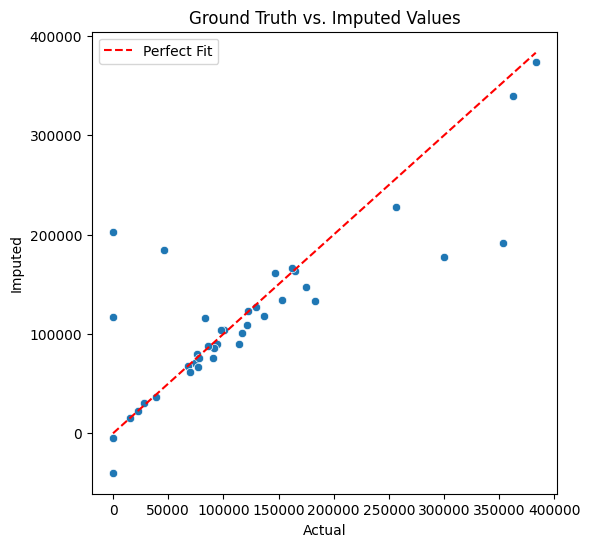

In [5]:
# 4. Verification
# Create a mask to identify where we originally introduced NaNs
missing_mask = df_missing.isnull()

# Extract the original true values and the new imputed values for those specific cells
actual_values = df_orig[missing_mask]
imputed_values = df_imputed[missing_mask]

# Combine them into a comparison DataFrame
comparison = pd.DataFrame({
    'Actual': actual_values.stack().values,
    'Imputed': imputed_values.stack().values
})

# Calculate Error Metrics
comparison['Abs_Error'] = (comparison['Actual'] - comparison['Imputed']).abs()
comparison['Pct_Error'] = (comparison['Abs_Error'] / comparison['Actual']) * 100

print("\n--- Verification Results (Sample) ---")
print(comparison.head(10))

print(f"\nMean Absolute Error (MAE): {comparison['Abs_Error'].mean():.4f}")
print(f"Mean Squared Error (MSE): {(comparison['Abs_Error']**2).mean():.4f}")

# Optional: Visualize the correlation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.scatterplot(x='Actual', y='Imputed', data=comparison)
plt.plot([comparison['Actual'].min(), comparison['Actual'].max()], 
         [comparison['Actual'].min(), comparison['Actual'].max()], 
         'r--', label='Perfect Fit')
plt.title("Ground Truth vs. Imputed Values")
plt.legend()
plt.show()
